# Vehicle Damage Classification for Insurance Claims

A 6-class image classifier that identifies the type of vehicle damage (crack, dent, glass shatter,
lamp broken, scratch, tire flat) from a photo — the kind of triage step an insurer could use to
route or pre-assess a claim.

Two approaches are compared:
- **Baseline CNN** — a small convolutional network trained from scratch.
- **Transfer learning** — a MobileNetV2 backbone (pretrained on ImageNet) with a new classification head.

The notebook ends with a held-out **test set** evaluation (not just validation accuracy), a
confusion matrix, and a saved model file ready for deployment.


In [1]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json
import os
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Conv2D, Dense, Dropout, GlobalAveragePooling2D, MaxPooling2D,
    Flatten, Rescaling, RandomFlip, RandomRotation, RandomZoom, BatchNormalization
)
from tensorflow.keras.applications import MobileNetV2, mobilenet_v2
from sklearn.metrics import confusion_matrix, classification_report


C:\Users\User\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
base_dir = "accident_pics/train/train"
inference_dir = "accident_pics/test/test"  # unlabeled images — no ground truth, used for predictions only
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE


In [3]:
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()


## Data

Images live in class-named subfolders under `accident_pics/train/train`. The `accident_pics/test/test`
folder turned out to be a flat folder of **unlabeled** images (no class subfolders) — useful for
generating predictions on, but not for evaluation, since there is no ground truth to check them against.

So the labeled data is split three ways instead: 70% train, 15% validation (used for early stopping
and comparing the two models), 15% **test** — a genuine held-out set with labels, touched only once,
at the very end, for the confusion matrix and final accuracy figure.


In [4]:
train_ds = image_dataset_from_directory(
    base_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.3,
    subset="training",
    seed=123,
)

holdout_ds = image_dataset_from_directory(
    base_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.3,
    subset="validation",
    seed=123,
)

# Split the 30% holdout evenly into validation (used during training) and test (touched once, at the end)
holdout_batches = tf.data.experimental.cardinality(holdout_ds).numpy()
val_ds = holdout_ds.take(holdout_batches // 2)
test_ds = holdout_ds.skip(holdout_batches // 2)

print(f"Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")


Found 7200 files belonging to 6 classes.
Using 5040 files for training.
Found 7200 files belonging to 6 classes.
Using 2160 files for validation.
Train batches: 315
Validation batches: 67
Test batches: 68


In [5]:
# Build the label map directly from what Keras actually assigned, rather than typing it by hand.
# image_dataset_from_directory assigns class indices alphabetically by folder name — a hand-typed
# dict is an easy way to silently mislabel predictions if the order doesn't match.
class_names = train_ds.class_names
labels = {i: name for i, name in enumerate(class_names)}
labels


{0: 'crack',
 1: 'dent',
 2: 'glass shatter',
 3: 'lamp broken',
 4: 'scratch',
 5: 'tire flat'}

In [6]:
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [7]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])


## Baseline CNN

A small convolutional network trained from scratch, as a reference point for how much transfer
learning actually buys us on this dataset.


In [8]:
model = Sequential([
    Input(shape=(224, 224, 3)),

    Rescaling(1./255),
    data_augmentation,

    Conv2D(32, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(len(class_names), activation="softmax")
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       6,422,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,813,766 (25.99 MB)

 Trainable params: 6,812,806 (25.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)


In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)


Epoch 1/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 314s 981ms/step - accuracy: 0.3873 - loss: 1.5773 - val_accuracy: 0.2976 - val_loss: 3.8373
Epoch 2/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 310s 982ms/step - accuracy: 0.4427 - loss: 1.3419 - val_accuracy: 0.4991 - val_loss: 1.1998
Epoch 3/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 304s 964ms/step - accuracy: 0.4651 - loss: 1.2766 - val_accuracy: 0.4925 - val_loss: 1.1845
Epoch 4/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - accuracy: 0.4804 - loss: 1.2425 - val_accuracy: 0.4851 - val_loss: 1.1989
Epoch 5/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 343s 1s/step - accuracy: 0.4915 - loss: 1.1835 - val_accuracy: 0.4459 - val_loss: 1.4321
Epoch 6/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 331s 1s/step - accuracy: 0.5063 - loss: 1.1560 - val_accuracy: 0.5028 - val_loss: 1.1554
Epoch 7/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 300s 953ms/step - accuracy: 0.5137 - loss: 1.1359 - val_accuracy: 0.5037 - val_loss: 1.1242
Epoch 8/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 303s 962ms/step - accuracy: 0.5159 - loss: 1.

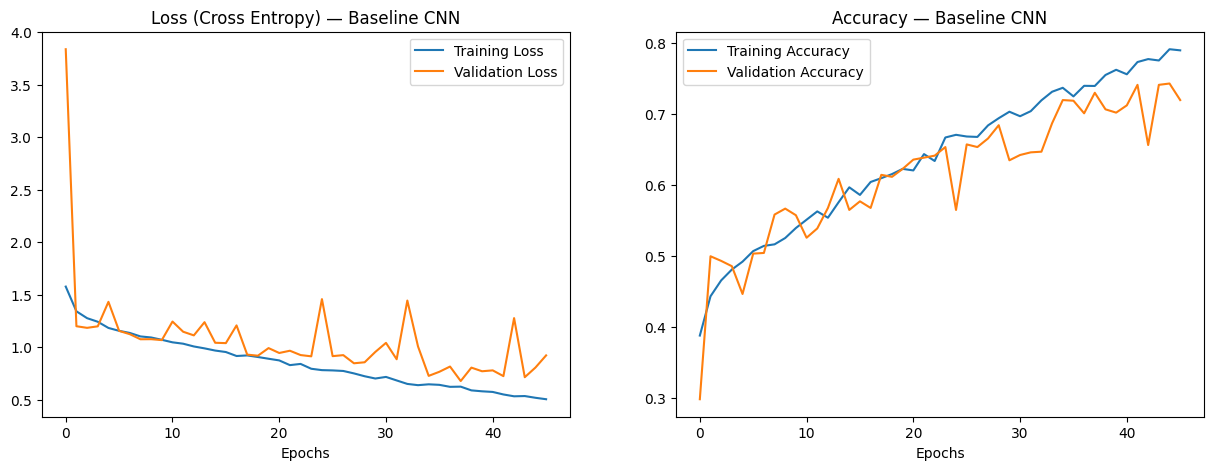

In [11]:
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history_df['loss'], label='Training Loss')
ax[0].plot(history_df['val_loss'], label='Validation Loss')
ax[0].set_title('Loss (Cross Entropy) — Baseline CNN')
ax[0].set_xlabel('Epochs')
ax[0].legend()

ax[1].plot(history_df['accuracy'], label='Training Accuracy')
ax[1].plot(history_df['val_accuracy'], label='Validation Accuracy')
ax[1].set_title('Accuracy — Baseline CNN')
ax[1].set_xlabel('Epochs')
ax[1].legend()

plt.savefig("baseline_cnn_history.png")
plt.show()


## Transfer learning: MobileNetV2

Same data, same augmentation strategy in spirit, but starting from ImageNet-pretrained weights
with the backbone frozen and only a new classification head trained.


In [12]:
tl_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
])

preprocess_input = mobilenet_v2.preprocess_input

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = tl_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model_tl = tf.keras.Model(inputs, outputs)

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 118s 354ms/step - accuracy: 0.5494 - loss: 1.1568 - val_accuracy: 0.6996 - val_loss: 0.8376
Epoch 2/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 108s 341ms/step - accuracy: 0.6873 - loss: 0.8067 - val_accuracy: 0.7220 - val_loss: 0.7340
Epoch 3/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 108s 342ms/step - accuracy: 0.7337 - loss: 0.7098 - val_accuracy: 0.7323 - val_loss: 0.6745
Epoch 4/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 112s 357ms/step - accuracy: 0.7724 - loss: 0.5852 - val_accuracy: 0.7668 - val_loss: 0.6096
Epoch 6/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 111s 353ms/step - accuracy: 0.7954 - loss: 0.5372 - val_accuracy: 0.7826 - val_loss: 0.5843
Epoch 7/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 108s 342ms/step - accuracy: 0.8026 - loss: 0.5168 - val_accuracy: 0.7957 - val_loss: 0.5605
Epoch 8/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 108s 342ms/step - accuracy: 0.8200 - loss: 0.4750 - val_accuracy: 0.7994 - val_loss: 0.5390
Epoch 9/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 108s 344ms/step - accuracy: 0.8256 -

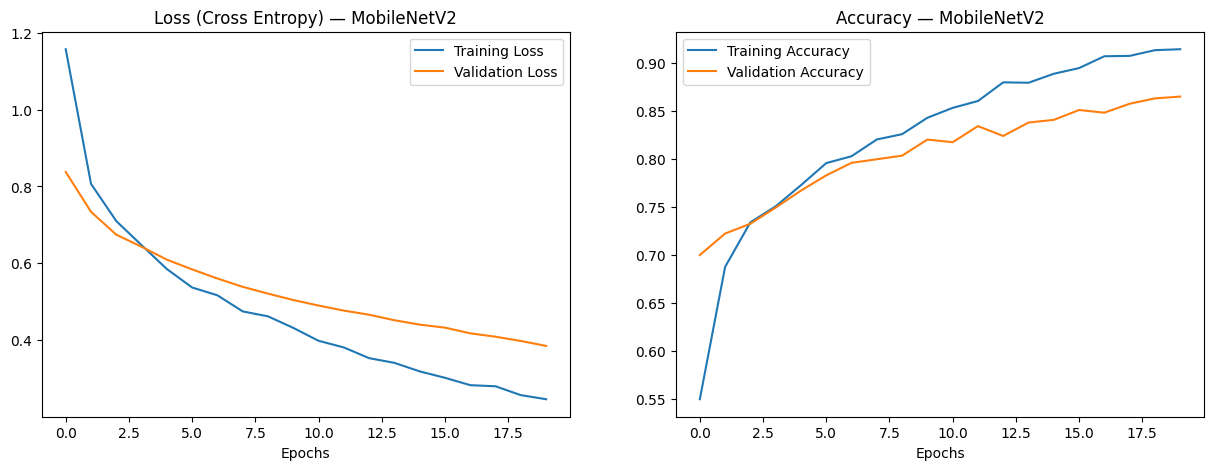

In [13]:
history_tl_df = pd.DataFrame(history_tl.history)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history_tl_df['loss'], label='Training Loss')
ax[0].plot(history_tl_df['val_loss'], label='Validation Loss')
ax[0].set_title('Loss (Cross Entropy) — MobileNetV2')
ax[0].set_xlabel('Epochs')
ax[0].legend()

ax[1].plot(history_tl_df['accuracy'], label='Training Accuracy')
ax[1].plot(history_tl_df['val_accuracy'], label='Validation Accuracy')
ax[1].set_title('Accuracy — MobileNetV2')
ax[1].set_xlabel('Epochs')
ax[1].legend()

plt.savefig("transfer_learning_history.png")
plt.show()


## Comparing the two models on validation accuracy

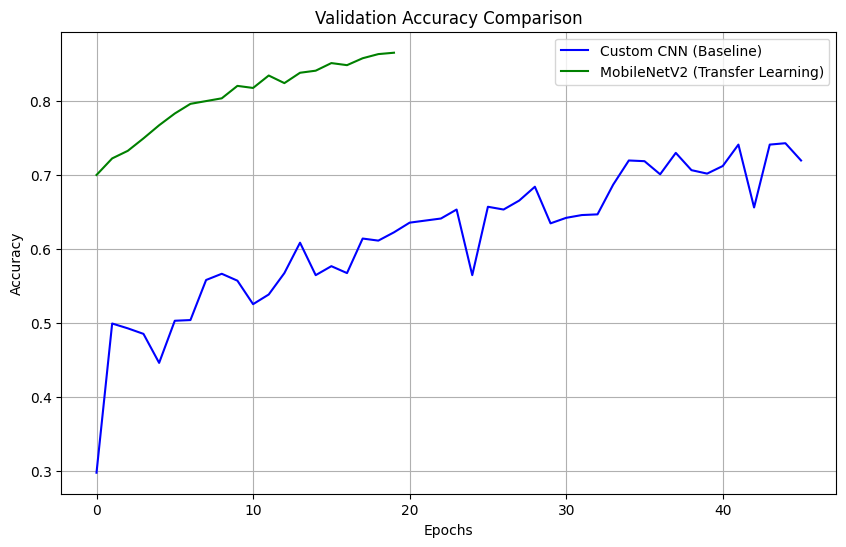

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], label='Custom CNN (Baseline)', color='blue')
plt.plot(history_tl.history['val_accuracy'], label='MobileNetV2 (Transfer Learning)', color='green')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("model_comparison.png")
plt.show()


## Final evaluation on the held-out test set

Everything above used validation accuracy to compare the two models — useful for model selection,
but it's the same data the training loop implicitly "saw" via early stopping. The test set below
was never touched until now, so this is the number that actually reflects real-world performance.


In [15]:
test_loss, test_accuracy = model_tl.evaluate(test_ds)
print(f"MobileNetV2 — Test accuracy: {test_accuracy:.4f} | Test loss: {test_loss:.4f}")


68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 303ms/step - accuracy: 0.8419 - loss: 0.4008
MobileNetV2 — Test accuracy: 0.8419 | Test loss: 0.4008


68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 279ms/step
               precision    recall  f1-score   support

        crack       0.83      0.43      0.57        23
         dent       0.76      0.86      0.81       310
glass shatter       0.98      0.94      0.96       190
  lamp broken       0.85      0.72      0.78       145
      scratch       0.82      0.82      0.82       335
    tire flat       0.95      0.93      0.94        85

     accuracy                           0.84      1088
    macro avg       0.87      0.79      0.81      1088
 weighted avg       0.85      0.84      0.84      1088



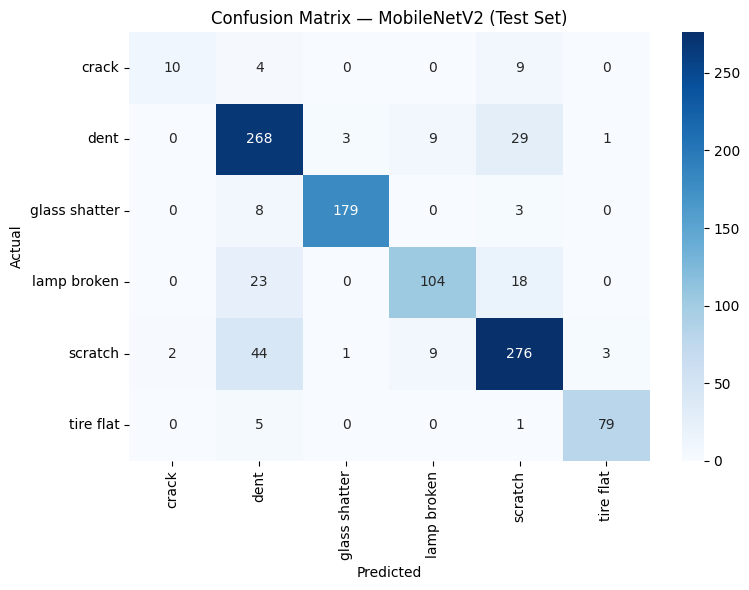

In [16]:
# Per-class performance — accuracy alone can hide a model that's bad at one or two damage types
y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred_probs = model_tl.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — MobileNetV2 (Test Set)')
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


## Saving the model for deployment

Saves the trained MobileNetV2 model and the class name mapping — both are needed by the
deployment app (`app.py`) to turn an uploaded image into a labelled prediction.


In [17]:
model_tl.save("vehicle_damage_mobilenetv2.keras")

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Saved model and class_names.json")


Saved model and class_names.json


## Predicting on the unlabeled images

These are the images from `accident_pics/test/test` — no ground truth, so this section produces
predictions rather than an accuracy score. Useful if this folder needs a submission file, or if you
just want to spot-check predictions on images the model has never seen in any form.


In [ ]:
inference_ds = image_dataset_from_directory(
    inference_dir,
    labels=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,  
)

file_paths = inference_ds.file_paths
inference_ds = inference_ds.cache().prefetch(buffer_size=AUTOTUNE)

pred_probs = model_tl.predict(inference_ds)
pred_indices = np.argmax(pred_probs, axis=1)
pred_labels = [class_names[i] for i in pred_indices]

predictions_df = pd.DataFrame({
    'filename': [p.split('/')[-1] for p in file_paths],
    'predicted_label': pred_labels,
    'confidence': pred_probs.max(axis=1)
})

predictions_df.to_csv('test_predictions.csv', index=False)
predictions_df.head()


Found 4800 files.
300/300 ━━━━━━━━━━━━━━━━━━━━ 107s 352ms/step


,filename,predicted_label,confidence
0,test\images\10000.jpg,lamp broken,0.667030
1,test\images\10001.jpg,scratch,0.895619
2,test\images\10002.jpg,scratch,0.996117
3,test\images\10003.jpg,dent,0.625116
4,test\images\10004.jpg,dent,0.623228


## Conclusion

MobileNetV2 reached **84.2% accuracy** on the held-out test set (1,088 images), clearly ahead of the
baseline CNN's ~74% validation accuracy from scratch training. This result held up across a clean,
full top-to-bottom rerun of the notebook — 84.2% vs. 84.0% on the first run — confirming the model
itself is stable rather than the earlier number being a fluke.

Per-class performance is uneven, and accuracy alone would have hidden this:

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Glass shatter | 0.98 | 0.94 | 0.96 | 190 |
| Tire flat | 0.95 | 0.93 | 0.94 | 85 |
| Scratch | 0.82 | 0.82 | 0.82 | 335 |
| Dent | 0.76 | 0.86 | 0.81 | 310 |
| Lamp broken | 0.85 | 0.72 | 0.78 | 145 |
| Crack | 0.83 | 0.43 | 0.57 | 23 |

- **Glass shatter and tire flat** are near-perfect — visually distinctive damage that the model
  rarely confuses with anything else.
- **Crack is the weak point** (recall 0.43 — the model misses more than half of actual cracks,
  consistent with 0.52 recall on the first run). It also has by far the smallest test support
  (23 images vs. 300+ for dent/scratch), so this looks like a **class imbalance problem** rather
  than cracks being inherently harder to classify. More labeled crack examples in training would
  likely close most of this gap.
- **Lamp broken** shows a smaller version of the same pattern (precision 0.85, recall 0.72) — the
  model is confident when it predicts lamp broken, but under-predicts that class overall.

**Production implication**: this model is reliable enough to auto-route the clearer damage types
(glass shatter, tire flat, dent, scratch) with high confidence, but crack and lamp broken
predictions — especially low-confidence ones — should be flagged for human review rather than
auto-approved, until more training data closes the imbalance.
